In [7]:
from decision_tree import DecisionTree
import numpy as np

In [8]:
X = np.array([
    [1, 2],
    [2, 1],
    [2, 3],
    [3, 2],
    [4, 5],
    [5, 4],
    [6, 7],
    [7, 6],
    [8, 8],
    [9, 7],
    [10, 9],
    [11, 10]
])

y = np.array([
    0, 0, 0, 0,
    1, 1, 1, 1,
    0, 0, 1, 1
])

In [9]:
model = DecisionTree(max_depth=4)
model.fit(X, y)

In [10]:
predictions = model.predict(X)
predictions

array([0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1])

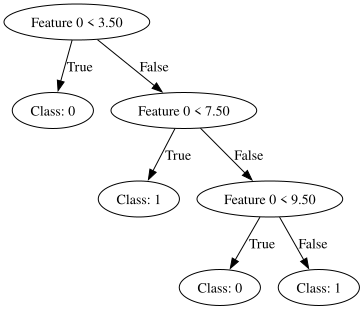

In [11]:
from graphviz import Digraph

dot = Digraph()

def add_nodes(node, node_id="0"):
    if node.value is not None:
        dot.node(node_id, f"Class: {node.value}")
        return

    dot.node(node_id, f"Feature {node.feature} < {node.threshold:.2f}")

    if node.left is not None:
        left_id = node_id + "L"
        add_nodes(node.left, left_id)
        dot.edge(node_id, left_id, label="True")

    if node.right is not None:
        right_id = node_id + "R"
        add_nodes(node.right, right_id)
        dot.edge(node_id, right_id, label="False")

add_nodes(model.root)

dot